In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload archive__8_.zip and archive__9_.zip

Saving archive (9).zip to archive (9).zip
Saving archive (8).zip to archive (8).zip


In [ ]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Extract zips
with zipfile.ZipFile('archive (8).zip', 'r') as z:
    z.extractall('.')
with zipfile.ZipFile('archive (9).zip', 'r') as z:
    z.extractall('.')

# Load datasets
twitter = pd.read_csv('Twitter_Data.csv')
reviews = pd.read_csv('user_reviews.csv')
apps = pd.read_csv('apps.csv')

print("=== Twitter Dataset ===")
print("Shape:", twitter.shape)
print(twitter.head(3))

print("\n=== User Reviews Dataset ===")
print("Shape:", reviews.shape)
print(reviews.head(3))

=== Twitter Dataset ===
Shape: (162980, 2)
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0

=== User Reviews Dataset ===
Shape: (64295, 5)
                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  


In [ ]:
print("=== Twitter Data Info ===")
print(twitter.dtypes)
print("\nMissing values:")
print(twitter.isnull().sum())
print("\nSentiment value counts:")
print(twitter['category'].value_counts())
print("\nSentiment meaning:")
print("-1 = Negative")
print(" 0 = Neutral")
print(" 1 = Positive")

=== Twitter Data Info ===
clean_text     object
category      float64
dtype: object

Missing values:
clean_text    4
category      7
dtype: int64

Sentiment value counts:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

Sentiment meaning:
-1 = Negative
 0 = Neutral
 1 = Positive


In [ ]:
# Drop missing values
twitter = twitter.dropna()
print("Shape after dropping nulls:", twitter.shape)

# Rename columns for clarity
twitter.columns = ['text', 'sentiment']

# Map sentiment numbers to labels
twitter['sentiment_label'] = twitter['sentiment'].map({
    -1: 'Negative',
     0: 'Neutral',
     1: 'Positive'
})

print("\nCleaned Twitter Data:")
print(twitter.head())
print("\nSentiment distribution:")
print(twitter['sentiment_label'].value_counts())

Shape after dropping nulls: (162969, 2)

Cleaned Twitter Data:
                                                text  sentiment  \
0  when modi promised “minimum government maximum...       -1.0   
1  talk all the nonsense and continue all the dra...        0.0   
2  what did just say vote for modi  welcome bjp t...        1.0   
3  asking his supporters prefix chowkidar their n...        1.0   
4  answer who among these the most powerful world...        1.0   

  sentiment_label  
0        Negative  
1         Neutral  
2        Positive  
3        Positive  
4        Positive  

Sentiment distribution:
sentiment_label
Positive    72249
Neutral     55211
Negative    35509
Name: count, dtype: int64


In [ ]:
# Drop missing reviews
reviews = reviews.dropna(subset=['Translated_Review', 'Sentiment'])
print("Reviews shape after cleaning:", reviews.shape)

print("\nSentiment distribution in reviews:")
print(reviews['Sentiment'].value_counts())

print("\nSample reviews:")
print(reviews[['Translated_Review', 'Sentiment']].head(5))

Reviews shape after cleaning: (37427, 5)

Sentiment distribution in reviews:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64

Sample reviews:
                                   Translated_Review Sentiment
0  I like eat delicious food. That's I'm cooking ...  Positive
1    This help eating healthy exercise regular basis  Positive
3         Works great especially going grocery store  Positive
4                                       Best idea us  Positive
5                                           Best way  Positive


In [ ]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)        # remove mentions and hashtags
    text = re.sub(r'[^a-z\s]', '', text)          # keep only letters
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text.strip()

# Apply cleaning
twitter['clean_text'] = twitter['text'].apply(clean_text)
reviews['clean_text'] = reviews['Translated_Review'].apply(clean_text)

print("=== Sample Cleaned Tweets ===")
print(twitter[['text', 'clean_text', 'sentiment_label']].head(5))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


=== Sample Cleaned Tweets ===
                                                text  \
0  when modi promised “minimum government maximum...   
1  talk all the nonsense and continue all the dra...   
2  what did just say vote for modi  welcome bjp t...   
3  asking his supporters prefix chowkidar their n...   
4  answer who among these the most powerful world...   

                                          clean_text sentiment_label  
0  modi promised minimum government maximum gover...        Negative  
1             talk nonsense continue drama vote modi         Neutral  
2  say vote modi welcome bjp told rahul main camp...        Positive  
3  asking supporters prefix chowkidar names modi ...        Positive  
4  answer among powerful world leader today trump...        Positive  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Twitter TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_twitter = tfidf.fit_transform(twitter['clean_text'])
y_twitter = twitter['sentiment']

print("TF-IDF Matrix shape (Twitter):", X_twitter.shape)
print("This means:", X_twitter.shape[0], "tweets and", X_twitter.shape[1], "features")

TF-IDF Matrix shape (Twitter): (162969, 5000)
This means: 162969 tweets and 5000 features


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_twitter, y_twitter, test_size=0.2, random_state=42)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

# Train model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict
y_pred = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nNaive Bayes Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Neutral', 'Positive']))

Training size: 130375
Testing size: 32594

Naive Bayes Accuracy: 72.71%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.44      0.58      7152
     Neutral       0.84      0.66      0.74     11067
    Positive       0.65      0.93      0.77     14375

    accuracy                           0.73     32594
   macro avg       0.79      0.67      0.70     32594
weighted avg       0.77      0.73      0.72     32594



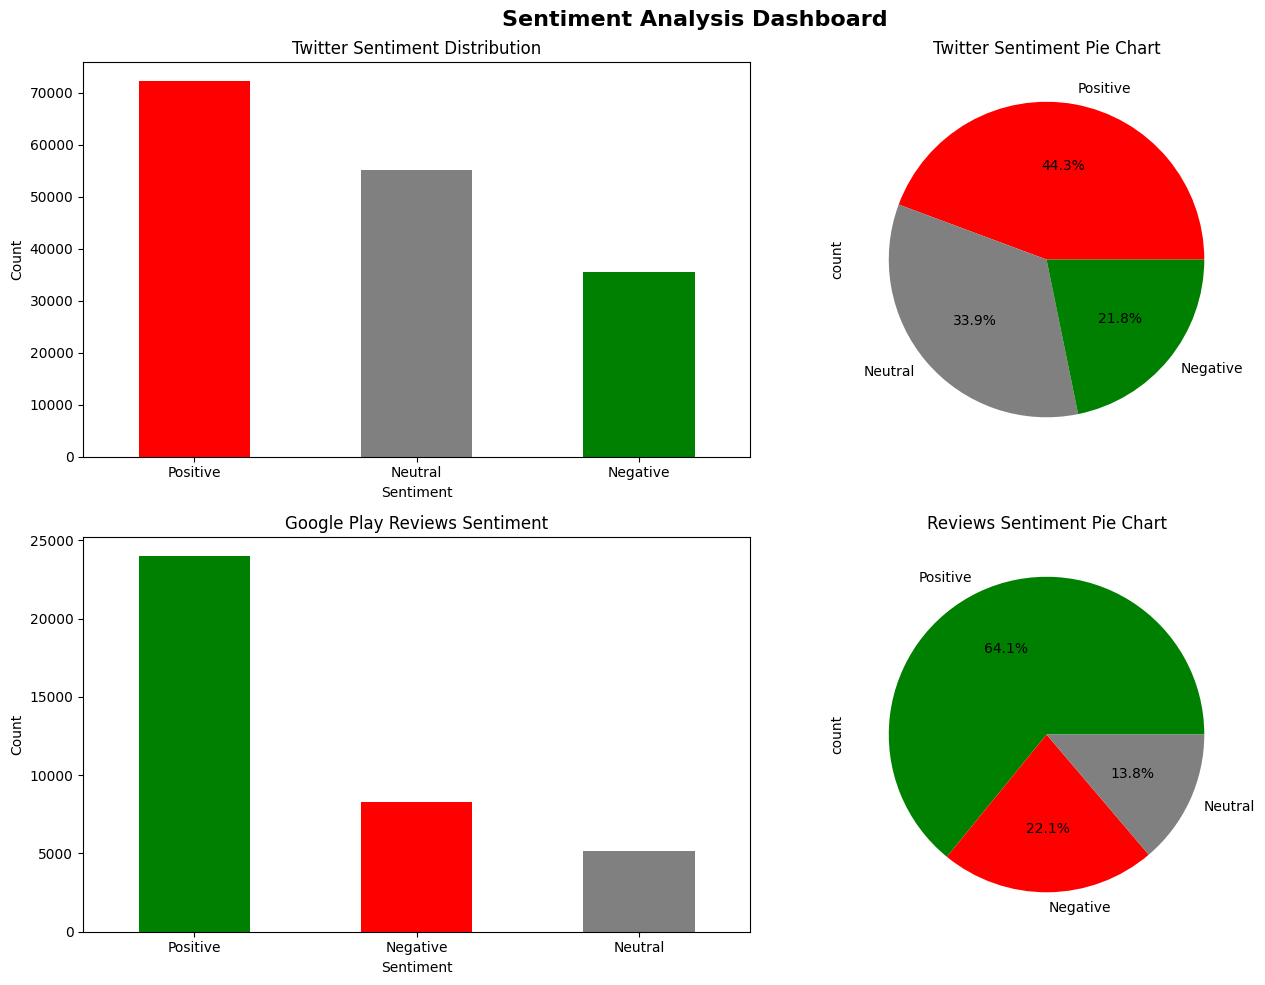

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Twitter sentiment distribution
twitter['sentiment_label'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['red','gray','green'])
axes[0,0].set_title('Twitter Sentiment Distribution')
axes[0,0].set_xlabel('Sentiment')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Chart 2 - Twitter sentiment pie chart
twitter['sentiment_label'].value_counts().plot(
    kind='pie', ax=axes[0,1], autopct='%1.1f%%',
    colors=['red','gray','green'])
axes[0,1].set_title('Twitter Sentiment Pie Chart')

# Chart 3 - Reviews sentiment distribution
reviews['Sentiment'].value_counts().plot(
    kind='bar', ax=axes[1,0], color=['green','red','gray'])
axes[1,0].set_title('Google Play Reviews Sentiment')
axes[1,0].set_xlabel('Sentiment')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=0)

# Chart 4 - Reviews sentiment pie chart
reviews['Sentiment'].value_counts().plot(
    kind='pie', ax=axes[1,1], autopct='%1.1f%%',
    colors=['green','red','gray'])
axes[1,1].set_title('Reviews Sentiment Pie Chart')

plt.suptitle('Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

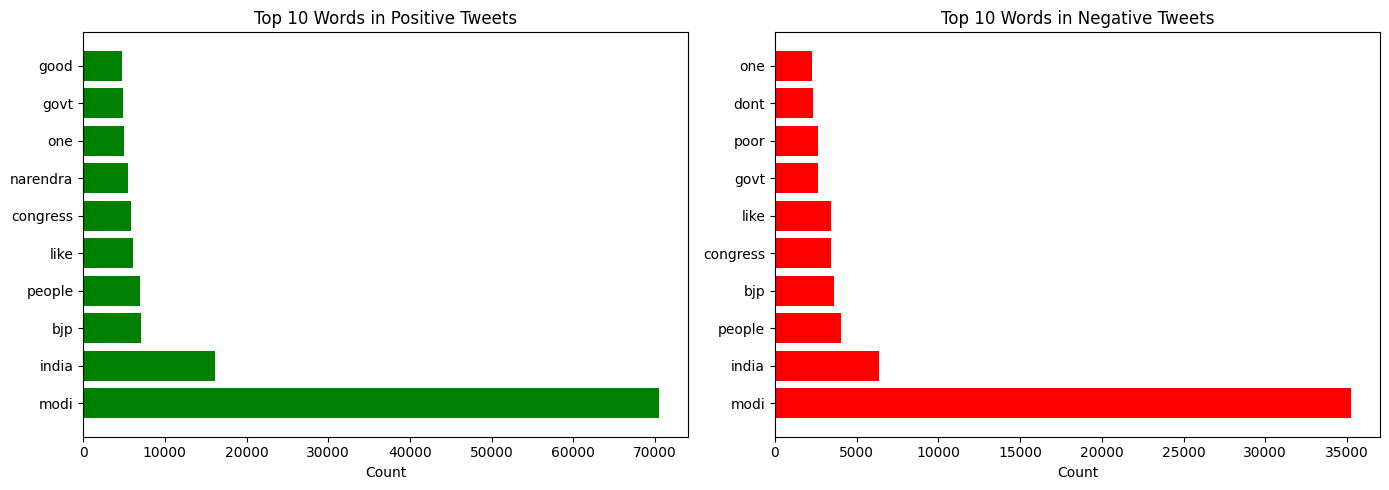

In [ ]:
from collections import Counter

# Most common words in positive tweets
positive_tweets = twitter[twitter['sentiment_label']=='Positive']['clean_text']
positive_words = ' '.join(positive_tweets).split()
positive_common = Counter(positive_words).most_common(10)

# Most common words in negative tweets
negative_tweets = twitter[twitter['sentiment_label']=='Negative']['clean_text']
negative_words = ' '.join(negative_tweets).split()
negative_common = Counter(negative_words).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive words
words, counts = zip(*positive_common)
axes[0].barh(list(words), list(counts), color='green')
axes[0].set_title('Top 10 Words in Positive Tweets')
axes[0].set_xlabel('Count')

# Negative words
words2, counts2 = zip(*negative_common)
axes[1].barh(list(words2), list(counts2), color='red')
axes[1].set_title('Top 10 Words in Negative Tweets')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = nb_model.predict(vectorized)[0]
    label = {-1: 'Negative 😠', 0: 'Neutral 😐', 1: 'Positive 😊'}
    return label[prediction]

# Test it!
test_sentences = [
    "I love this product it is amazing!",
    "This is the worst experience ever",
    "The weather is okay today",
    "Modi is doing great work for India",
    "I hate this so much it is terrible"
]

print("=== SENTIMENT PREDICTIONS ===\n")
for sentence in test_sentences:
    result = predict_sentiment(sentence)
    print(f"Text: {sentence}")
    print(f"Sentiment: {result}\n")

=== SENTIMENT PREDICTIONS ===

Text: I love this product it is amazing!
Sentiment: Positive 😊

Text: This is the worst experience ever
Sentiment: Negative 😠

Text: The weather is okay today
Sentiment: Positive 😊

Text: Modi is doing great work for India
Sentiment: Positive 😊

Text: I hate this so much it is terrible
Sentiment: Negative 😠



=== ALGORITHM COMPARISON ===

Naive Bayes: 72.71%
Logistic Regression: 89.22%
Linear SVM: 90.24%


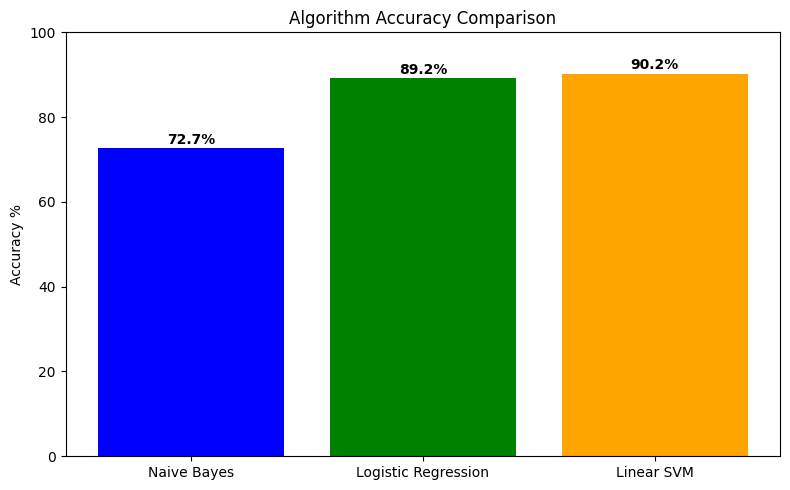

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC(max_iter=1000)
}

print("=== ALGORITHM COMPARISON ===\n")
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc * 100
    print(f"{name}: {acc*100:.2f}%")

# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['blue','green','orange'])
plt.title('Algorithm Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(0, 100)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("=== SENTIMENT ANALYSIS PROJECT SUMMARY ===\n")
print(f"Twitter Dataset: {twitter.shape[0]} tweets analyzed")
print(f"Reviews Dataset: {reviews.shape[0]} reviews analyzed")
print(f"\nTwitter Sentiment Distribution:")
for label, count in twitter['sentiment_label'].value_counts().items():
    pct = count/len(twitter)*100
    print(f"  {label}: {count} tweets ({pct:.1f}%)")
print(f"\nBest Model: {max(results, key=results.get)}")
print(f"Best Accuracy: {max(results.values()):.2f}%")
print("\nKey Findings:")
print("  ✅ Successfully classified tweets as Positive, Negative, Neutral")
print("  ✅ TF-IDF used for feature extraction")
print("  ✅ Multiple ML algorithms compared")
print("  ✅ Google Play reviews sentiment analyzed")
print("\nSentiment Analysis helps businesses understand")
print("customer opinions and social media trends! 🎉")

=== SENTIMENT ANALYSIS PROJECT SUMMARY ===

Twitter Dataset: 162969 tweets analyzed
Reviews Dataset: 37427 reviews analyzed

Twitter Sentiment Distribution:
  Positive: 72249 tweets (44.3%)
  Neutral: 55211 tweets (33.9%)
  Negative: 35509 tweets (21.8%)

Best Model: Linear SVM
Best Accuracy: 90.24%

Key Findings:
  ✅ Successfully classified tweets as Positive, Negative, Neutral
  ✅ TF-IDF used for feature extraction
  ✅ Multiple ML algorithms compared
  ✅ Google Play reviews sentiment analyzed

Sentiment Analysis helps businesses understand
customer opinions and social media trends! 🎉
